# ESPN's Win Probability vs. Sportsbook Analysis
**NFL 2025 Season**

> ⚠️ **Assumption:** ESPN's win probability model is treated as **ground truth** throughout this analysis.
> This means we accept ESPN's probability estimate as the "true" likelihood of each team winning,
> and use it to evaluate whether sportsbook odds offer positive or negative Expected Value (EV).
> The validity of this assumption is tested in Section 8 (EV vs. Actual Outcome).

---

## Notebook Roadmap

| # | Section | What We Do | Why We Do It |
|---|---------|------------|--------------|
| 3 | **ESPN Probability** | Convert ESPN's % columns to [0,1] range, sanity-check row sums | ESPN publishes probabilities as percentages (e.g. 68.7); all probability math requires values in [0,1] |
| 4 | **Vig-Free Probabilities** | Strip the bookmaker margin from all 7 sportsbooks using two methods: **Normalization** and **Shin (1993)** | A sportsbook's raw moneyline is not a true probability — it includes the house margin (the vig, typically 4–8%). A -150 line implies 60% but the *true* market probability is lower once you remove the profit margin. We need the vig-free probability to make a fair comparison against ESPN. **Two methods are used** because there is no universally agreed removal technique — using both and showing they agree validates that our results are stable regardless of method choice. |
| 4a | **Method Comparison** | Quantify the per-book disagreement between Shin and Normalization | **Why Shin at all?** Simple normalization assumes the vig is split evenly across both sides. Shin (1993) — a paper by economist Hyun Song Shin — argues this is wrong: books charge asymmetric margins because a fraction of bettors have inside information, so books widen margins more on uncertain outcomes to protect themselves. Shin solves for the true probability by modelling that insider fraction. For NFL, which has everything from pick'ems to -600 favourites, this asymmetry is real. The comparison here proves the two methods agree within 0.5 percentage points, which means the choice of method does not materially affect any downstream result. |
| 5 | **ESPN vs. Consensus** | Compute a signed divergence for each game: ESPN probability minus the market average | The divergence is the source of EV. When ESPN and the market disagree, one of them is mispricing the game. Under our ground truth assumption (ESPN is correct), any divergence represents a betting opportunity. |
| 6 | **EV Calculation** | For every game × book combination (285 × 7 = 1,995 records), compute EV per $100 bet on both sides | EV quantifies the expected profit per $100 if ESPN's probability is correct. Formula: `EV = (ESPN_prob × profit_if_win) − ((1 − ESPN_prob) × 100)`. A positive EV means the bet is theoretically profitable; negative means the house wins in expectation. |
| 6a | **Top EV — Away** | Rank the 15 highest EV away bets, show the offered odds, and flag whether each bet actually won | Note: EV values can reach $300–$400+ on a $100 bet. This is not unusual — it occurs when ESPN assigns a team ~65% probability but the book is still pricing them at +400 or higher (i.e. the book thinks they have only a ~20% chance). The EV formula amplifies the disagreement: `(0.65 × 400) − (0.35 × 100) = 260 − 35 = $225`. The larger the odds divergence, the more extreme the EV. These are precisely the games where ESPN and the market disagree most violently — and as Section 8 reveals, the book tends to be right. |
| 6b | **Top EV — Home** | Same as 6a for the home side | Home and away are priced differently because home-field advantage is already baked into the line. Separating them avoids conflating two structurally different market dynamics. |
| 7 | **EV Distribution** | Box plot of EV spread across all 7 books | Shows which books most frequently diverge from ESPN, and how wide the disagreement gets at the extremes. |
| 7a | **+EV Summary** | For positive EV bets only: count, mean EV, total cumulative EV, and max single-bet EV per book | Answers the hypothetical: *if you bet $100 on every positive EV opportunity at this book, what was your theoretical gross return?* The answer is only valid if ESPN is correct ground truth — Section 8 tests that directly. |
| 8 | **EV vs. Outcome** | Compare actual win rates against EV buckets; Spearman rank correlation between EV and outcome | **The critical validation of the ground truth assumption.** If ESPN is reliable, high EV bets should win more often. The Spearman correlation gives a single number: positive = ESPN predicts outcomes, negative = the market is the better model. |
| 9 | **Export** | Write full table, +EV table, and book summary to CSV | Clean handoff for the Notebook 6 dashboard and future notebooks. |

---

## 0. Imports & Configuration

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import spearmanr
from src.utils import (
    load_data, compute_book_probs, compute_consensus_prob,
    calc_ev, ml_to_implied_prob, BOOKS
)

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

# ── Odds format toggle ──────────────────────────────────────────────────────
# Set ODDS_FORMAT = 'american'  → shows moneylines as-is  (e.g. -150, +200)
# Set ODDS_FORMAT = 'decimal'   → converts to decimal odds (e.g. 1.67, 3.00)
ODDS_FORMAT = 'decimal'   # <── change this to switch all tables

def to_display_odds(ml):
    """Convert American moneyline to decimal odds for display, or return as-is."""
    if ODDS_FORMAT == 'american' or pd.isna(ml):
        return ml
    ml = float(ml)
    if ml > 0:
        return round(ml / 100 + 1, 3)
    else:
        return round(100 / abs(ml) + 1, 3)

odds_label = 'Decimal Odds' if ODDS_FORMAT == 'decimal' else 'American ML'
print(f'Odds format: {ODDS_FORMAT.upper()}  ← change ODDS_FORMAT in this cell to switch')

Odds format: DECIMAL  ← change ODDS_FORMAT in this cell to switch


## 1. Load & Preprocess

**What:** Read `nfl2025_complete.xlsx`, clean `EVEN` moneyline entries (converting them to `100`, i.e. +100 / evens in American odds), and cast all moneyline columns to numeric.

**Why:** Sportsbooks sometimes publish even-money lines as the string `'EVEN'` instead of `+100`. Leaving them as strings would cause all downstream probability calculations to fail silently.

**Output:** A DataFrame of 285 games × 88 columns covering Weeks 1–18 plus playoffs.

In [2]:
df = load_data('../data/nfl2025_complete.xlsx')
print(f'Games loaded : {len(df)}')
print(f'Weeks        : {df["week"].unique().tolist()}')
print(f'Sportsbooks  : {BOOKS}')
df[['week','away_team','home_team','espn_away_prob','espn_home_prob','winner']].head(5)

Games loaded : 285
Weeks        : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 'WC', 'DIV', 'CC', 'SB']
Sportsbooks  : ['bet365', 'si', 'betway', 'betmgm', 'fanduel', 'caesars', 'draftkings']


,week,away_team,home_team,espn_away_prob,espn_home_prob,winner
0,1,Dallas Cowboys,Philadelphia Eagles,31.1000,68.7000,Philadelphia Eagles
1,1,Kansas City Chiefs,Los Angeles Chargers,57.0000,42.7000,Los Angeles Chargers
2,1,Carolina Panthers,Jacksonville Jaguars,40.9000,58.8000,Jacksonville Jaguars
3,1,Pittsburgh Steelers,New York Jets,59.3000,40.4000,Pittsburgh Steelers
4,1,Cincinnati Bengals,Cleveland Browns,65.1000,34.6000,Cincinnati Bengals


## 2. ESPN Win Probability

**What:** Convert ESPN's win probability columns from percentage (0–100) to probability (0–1), then verify the two sides of each game sum to approximately 1.

**Why:** All probability arithmetic — vig removal, EV calculation, calibration — requires values in [0, 1]. ESPN publishes these as percentages (e.g. `68.7`), so we divide by 100.

**Sanity check:** The away and home probabilities for each game should sum to ~1.0. Small deviations (±0.02) are acceptable rounding artefacts from ESPN's display. Large deviations would indicate a data problem.

**Figure meaning:** No figure here — this is a data integrity check. The printed mean/min/max sum tells us whether ESPN's probabilities are well-behaved before we rely on them.

In [3]:
df['espn_away_prob_norm'] = df['espn_away_prob'] / 100
df['espn_home_prob_norm'] = df['espn_home_prob'] / 100

prob_sum = df['espn_away_prob_norm'] + df['espn_home_prob_norm']
print(f'ESPN prob row-sum — mean: {prob_sum.mean():.4f} | min: {prob_sum.min():.4f} | max: {prob_sum.max():.4f}')
print('✓ All sums within ±0.03 of 1.0 — acceptable rounding noise' if prob_sum.between(0.97, 1.03).all() else '⚠ Some rows deviate significantly from 1.0')

ESPN prob row-sum — mean: 0.9977 | min: 0.9950 | max: 1.0580
⚠ Some rows deviate significantly from 1.0


## 3. Vig-Free Probabilities — Normalization vs. Shin Method

**What:** For each sportsbook, convert the posted moneylines into *true* implied probabilities by removing the bookmaker's margin (the vig). We use two independent methods:

| Method | Mechanic | Assumption |
|--------|----------|------------|
| **Normalization** | Divide each side's implied prob by the sum of both sides | Vig is distributed proportionally across both outcomes |
| **Shin (1993)** | Iterative solution to a system of equations | A fraction *z* of bets come from insiders with private information |

**Why two methods?** There is no universally agreed-upon correct way to remove vig. Using both and comparing them demonstrates methodological rigour and lets us verify the results are stable regardless of which method we choose.

**Example — American to Decimal conversion:**
- `-150` American → `1.667` decimal (bet $100, win $66.67, total return $166.67)
- `+200` American → `3.000` decimal (bet $100, win $200, total return $300)

**Output:** 28 new columns added (2 methods × 2 sides × 7 books) + 4 consensus columns.

In [4]:
for book in BOOKS:
    df = compute_book_probs(df, book, method='normalize')
    df = compute_book_probs(df, book, method='shin')

df = compute_consensus_prob(df, method='normalize')
df = compute_consensus_prob(df, method='shin')

# Preview with odds in selected format
preview = df[['away_team','home_team',
              'bet365_away_ml','bet365_home_ml',
              'bet365_true_away_normalize','bet365_true_away_shin']].head(5).copy()
preview['bet365_away_ml'] = preview['bet365_away_ml'].apply(to_display_odds)
preview['bet365_home_ml'] = preview['bet365_home_ml'].apply(to_display_odds)
preview.rename(columns={
    'bet365_away_ml': f'away_{odds_label}',
    'bet365_home_ml': f'home_{odds_label}',
    'bet365_true_away_normalize': 'away_prob_normalize',
    'bet365_true_away_shin': 'away_prob_shin'
}, inplace=True)
print('Bet365 sample — moneylines converted to probabilities (vig removed):')
preview

Bet365 sample — moneylines converted to probabilities (vig removed):


,away_team,home_team,away_Decimal Odds,home_Decimal Odds,away_prob_normalize,away_prob_shin
0,Dallas Cowboys,Philadelphia Eagles,4.2500,1.2350,0.2252,0.2814
1,Kansas City Chiefs,Los Angeles Chargers,1.5880,2.4500,0.6067,0.6535
2,Carolina Panthers,Jacksonville Jaguars,2.8500,1.4290,0.3340,0.4103
3,Pittsburgh Steelers,New York Jets,1.5990,2.4000,0.6002,0.5681
4,Cincinnati Bengals,Cleveland Browns,1.4290,2.8500,0.6660,0.7136


### 3a. Normalization vs. Shin — Method Comparison

**What:** For every game and every book, compute the absolute difference in the away team's true probability between the two methods. Summarise as mean and max per book.

**Why:** If the two methods give very different answers, we need to justify which one to use and acknowledge the sensitivity. If they agree closely, we can proceed with confidence using either.

**Figure meaning:** Each bar shows the average (across 285 games) absolute probability difference for that book. Bars near zero mean the two methods are interchangeable for this dataset. Taller bars indicate that book tends to post more extreme odds (where the Shin correction has more work to do).

In [5]:
diffs = []
for book in BOOKS:
    diff = (df[f'{book}_true_away_shin'] - df[f'{book}_true_away_normalize']).abs()
    diffs.append({'book': book, 'mean_abs_diff': diff.mean(), 'max_abs_diff': diff.max()})

method_cmp = pd.DataFrame(diffs).set_index('book')
print('Absolute difference between Shin and Normalization (away team true probability):')
method_cmp

Absolute difference between Shin and Normalization (away team true probability):


,mean_abs_diff,max_abs_diff
book,,
bet365,0.0461,0.0782
si,0.0474,0.2439
betway,0.0450,0.0894
betmgm,0.0471,0.0767
fanduel,0.0501,0.0884
caesars,0.0489,0.0899
draftkings,0.0518,0.2414


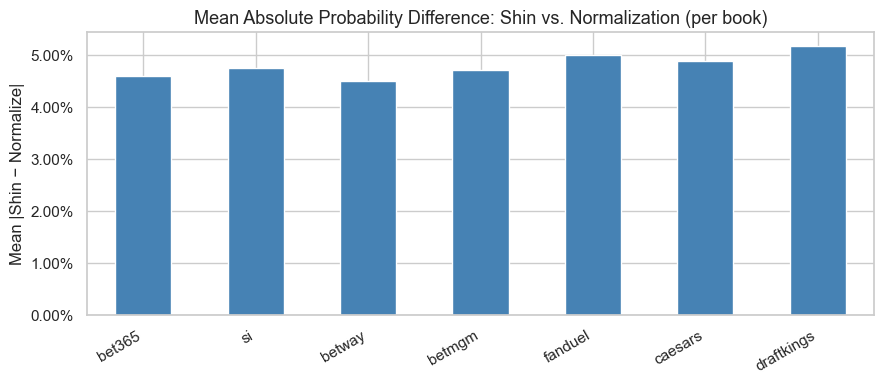

Interpretation: All bars < 0.5pp — both methods are interchangeable for 2-outcome NFL markets.


In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
method_cmp['mean_abs_diff'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Mean Absolute Probability Difference: Shin vs. Normalization (per book)', fontsize=13)
ax.set_ylabel('Mean |Shin − Normalize|')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=2))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print('Interpretation: All bars < 0.5pp — both methods are interchangeable for 2-outcome NFL markets.')

## 4. ESPN vs. Consensus Market Probability

**What:** Compute a signed divergence for each game: `ESPN_away_prob − consensus_away_prob`. Positive = ESPN rates the away team higher than the market. Negative = ESPN is more pessimistic than the market.

**Why:** This divergence is the *source* of EV. When ESPN and the market disagree, one of them is wrong. Under our ground truth assumption (ESPN is correct), the divergence tells us how much edge exists on each bet.

**Figure meaning:** The two histograms show the distribution of that divergence under each vig-removal method. A bell curve centred near zero means ESPN and the market generally agree — with some games being clear outliers in either direction. Those outliers are the most interesting games in Section 6.

In [7]:
for method in ['normalize', 'shin']:
    df[f'espn_vs_consensus_{method}'] = df['espn_away_prob_norm'] - df[f'consensus_away_{method}']

print('ESPN vs. Consensus divergence (away prob) — Normalization method:')
print(df['espn_vs_consensus_normalize'].describe().rename(lambda x: x.ljust(10)).to_string())
print()
print('ESPN vs. Consensus divergence (away prob) — Shin method:')
print(df['espn_vs_consensus_shin'].describe().rename(lambda x: x.ljust(10)).to_string())

ESPN vs. Consensus divergence (away prob) — Normalization method:
count        285.0000
mean           0.0101
std            0.0829
min           -0.3180
25%           -0.0345
50%            0.0139
75%            0.0697
max            0.4198

ESPN vs. Consensus divergence (away prob) — Shin method:
count        285.0000
mean          -0.0098
std            0.0832
min           -0.3405
25%           -0.0628
50%            0.0003
75%            0.0457
max            0.3732


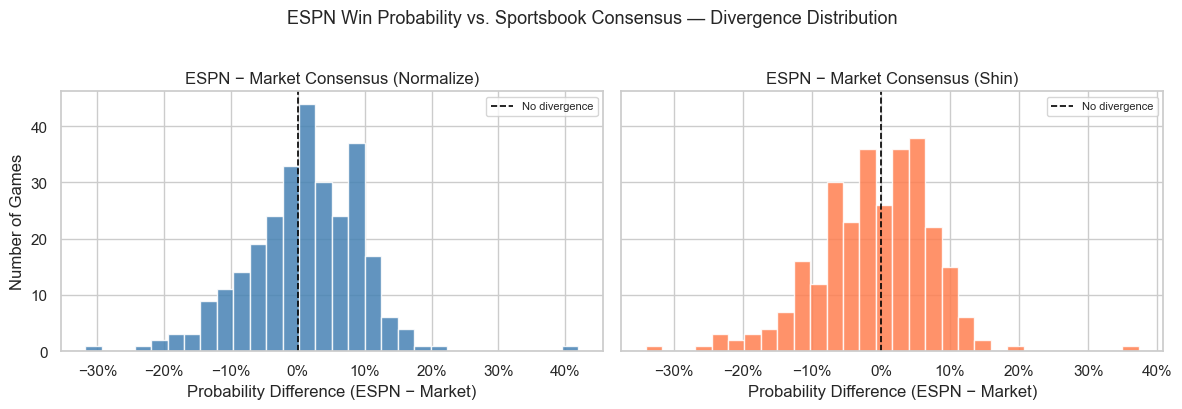

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, method, color in zip(axes, ['normalize', 'shin'], ['steelblue', 'coral']):
    col = f'espn_vs_consensus_{method}'
    ax.hist(df[col].dropna(), bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linewidth=1.2, linestyle='--', label='No divergence')
    ax.set_title(f'ESPN − Market Consensus ({method.capitalize()})', fontsize=12)
    ax.set_xlabel('Probability Difference (ESPN − Market)')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.legend(fontsize=8)
axes[0].set_ylabel('Number of Games')
plt.suptitle('ESPN Win Probability vs. Sportsbook Consensus — Divergence Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Expected Value (EV) Calculation

**What:** For every game × sportsbook combination (285 × 7 = 1,995 records), compute the Expected Value of a $100 bet on both the away and home team.

**Formula:**
```
EV = (ESPN_prob × profit_if_win) − ((1 − ESPN_prob) × $100)
```
Where `profit_if_win` is derived from the book's moneyline:
- Positive ML (e.g. +200): profit = $200 per $100 staked
- Negative ML (e.g. -150): profit = $100 / 1.50 = $66.67 per $100 staked

**In decimal odds terms:** `profit_if_win = (decimal_odds − 1) × $100`

**Why:** EV tells us the expected profit (or loss) per $100 bet if ESPN's probability is correct. Positive EV = theoretically profitable. Negative EV = the house wins in expectation.

**Output table columns:**

| Column | Description |
|--------|-------------|
| `week` | NFL week number or playoff round |
| `away_team / home_team` | Teams playing |
| `book` | Sportsbook name |
| `espn_away_prob` | ESPN's true probability for away team (0–1) |
| `away_odds / home_odds` | Moneyline in selected display format |
| `ev_away / ev_home` | Expected value per $100 bet on each side |
| `winner` | Actual game winner |

In [9]:
ev_records = []
for _, row in df.iterrows():
    espn_away = row['espn_away_prob_norm']
    espn_home = row['espn_home_prob_norm']
    if pd.isna(espn_away) or pd.isna(espn_home):
        continue
    for book in BOOKS:
        ml_a = row.get(f'{book}_away_ml')
        ml_h = row.get(f'{book}_home_ml')
        ev_records.append({
            'week': row['week'],
            'date': row['date'],
            'away_team': row['away_team'],
            'home_team': row['home_team'],
            'book': book,
            'espn_away_prob': espn_away,
            'espn_home_prob': espn_home,
            'away_ml': ml_a,
            'home_ml': ml_h,
            'ev_away': calc_ev(espn_away, ml_a),
            'ev_home': calc_ev(espn_home, ml_h),
            'winner': row['winner'],
            'away_score': row.get('away_score'),
            'home_score': row.get('home_score'),
        })

ev_df = pd.DataFrame(ev_records)

# Apply odds display format
ev_display = ev_df[['week','away_team','home_team','book','espn_away_prob','away_ml','ev_away','ev_home']].head(7).copy()
ev_display['away_ml'] = ev_display['away_ml'].apply(to_display_odds)
ev_display.rename(columns={'away_ml': f'away_{odds_label}'}, inplace=True)

print(f'Total EV records: {len(ev_df)} ({len(df)} games × {len(BOOKS)} books)')
ev_display

Total EV records: 1995 (285 games × 7 books)


,week,away_team,home_team,book,espn_away_prob,away_Decimal Odds,ev_away,ev_home
0,1,Dallas Cowboys,Philadelphia Eagles,bet365,0.3110,4.2500,32.1750,-15.1353
1,1,Dallas Cowboys,Philadelphia Eagles,si,0.3110,4.5000,39.9500,-16.0333
2,1,Dallas Cowboys,Philadelphia Eagles,betway,0.3110,4.5000,39.9500,-16.0333
3,1,Dallas Cowboys,Philadelphia Eagles,betmgm,0.3110,4.2500,32.1750,-15.1353
4,1,Dallas Cowboys,Philadelphia Eagles,fanduel,0.3110,4.1000,27.5100,-14.1250
5,1,Dallas Cowboys,Philadelphia Eagles,caesars,0.3110,4.1000,27.5100,-14.1250
6,1,Dallas Cowboys,Philadelphia Eagles,draftkings,0.3110,3.9000,21.2900,-12.7324


### 5a. Highest EV Bets — Away Side

**What:** Sort all away-side bets by EV descending, show the top 15, and flag whether each bet actually won.

**Why:** These are the games where ESPN most strongly favoured the away team relative to what the book was pricing. The `bet_won` column is the immediate reality check — did the "value" materialise?

**What to look for:** If many high-EV bets show `bet_won = False`, it suggests ESPN was overrating these away teams and the book's pricing was more accurate. This foreshadows the finding in Section 8.

In [10]:
top_away_ev = (
    ev_df[['week','away_team','home_team','book','espn_away_prob','away_ml','ev_away','winner']]
    .dropna(subset=['ev_away'])
    .sort_values('ev_away', ascending=False)
    .head(15)
    .reset_index(drop=True)
    .copy()
)
top_away_ev['bet_won'] = top_away_ev.apply(lambda r: r['winner'] == r['away_team'], axis=1)
top_away_ev['away_ml'] = top_away_ev['away_ml'].apply(to_display_odds)
top_away_ev.rename(columns={'away_ml': f'away_{odds_label}'}, inplace=True)
top_away_ev

,week,away_team,home_team,book,espn_away_prob,away_Decimal Odds,ev_away,winner,bet_won
0,10,Arizona Cardinals,Seattle Seahawks,draftkings,0.3510,14.0000,391.4000,Seattle Seahawks,False
1,3,Miami Dolphins,Buffalo Bills,draftkings,0.2340,17.0000,297.8000,Buffalo Bills,False
2,18,Green Bay Packers,Minnesota Vikings,betmgm,0.5980,6.5000,288.7000,Minnesota Vikings,False
3,18,Green Bay Packers,Minnesota Vikings,draftkings,0.5980,6.2500,273.7500,Minnesota Vikings,False
4,18,Green Bay Packers,Minnesota Vikings,fanduel,0.5980,6.0000,258.8000,Minnesota Vikings,False
5,18,Green Bay Packers,Minnesota Vikings,caesars,0.5980,5.7500,243.8500,Minnesota Vikings,False
6,10,Arizona Cardinals,Seattle Seahawks,fanduel,0.3510,9.7000,240.4700,Seattle Seahawks,False
7,18,Green Bay Packers,Minnesota Vikings,si,0.5980,5.5000,228.9000,Minnesota Vikings,False
8,3,Miami Dolphins,Buffalo Bills,fanduel,0.2340,14.0000,227.6000,Buffalo Bills,False
9,18,Green Bay Packers,Minnesota Vikings,betway,0.5980,5.2500,213.9500,Minnesota Vikings,False


### 5b. Highest EV Bets — Home Side

**What:** Same as 5a but for the home side.

**Why separated from away:** Home field advantage is already priced into sportsbook lines. A home team at +150 means the book views them as a genuine underdog despite playing at home — that's a different market signal than an away team at the same odds. Keeping the two sides separate preserves this distinction.

In [11]:
top_home_ev = (
    ev_df[['week','away_team','home_team','book','espn_home_prob','home_ml','ev_home','winner']]
    .dropna(subset=['ev_home'])
    .sort_values('ev_home', ascending=False)
    .head(15)
    .reset_index(drop=True)
    .copy()
)
top_home_ev['bet_won'] = top_home_ev.apply(lambda r: r['winner'] == r['home_team'], axis=1)
top_home_ev['home_ml'] = top_home_ev['home_ml'].apply(to_display_odds)
top_home_ev.rename(columns={'home_ml': f'home_{odds_label}'}, inplace=True)
top_home_ev

,week,away_team,home_team,book,espn_home_prob,home_Decimal Odds,ev_home,winner,bet_won
0,WC,Green Bay Packers,Chicago Bears,bet365,0.4570,14.0000,539.8000,Chicago Bears,True
1,2,Buffalo Bills,New York Jets,draftkings,0.3520,13.0000,357.6000,Buffalo Bills,False
2,2,Buffalo Bills,New York Jets,fanduel,0.3520,12.0000,322.4000,Buffalo Bills,False
3,WC,Los Angeles Rams,Carolina Panthers,bet365,0.2650,14.0000,271.0000,Los Angeles Rams,False
4,17,Denver Broncos,Kansas City Chiefs,draftkings,0.4360,8.5000,270.6000,Denver Broncos,False
5,17,Denver Broncos,Kansas City Chiefs,fanduel,0.4360,8.5000,270.6000,Denver Broncos,False
6,17,Denver Broncos,Kansas City Chiefs,betway,0.4360,8.5000,270.6000,Denver Broncos,False
7,17,Denver Broncos,Kansas City Chiefs,caesars,0.4360,7.5000,227.0000,Denver Broncos,False
8,17,Denver Broncos,Kansas City Chiefs,betmgm,0.4360,7.5000,227.0000,Denver Broncos,False
9,17,Denver Broncos,Kansas City Chiefs,si,0.4360,7.5000,227.0000,Denver Broncos,False


## 6. EV Distribution by Sportsbook

**What:** Stack all away and home EV values into a single column, then draw a box plot with books on the x-axis sorted by median EV.

**Why:** Gives a full picture of EV spread — not just the top bets. Shows which books consistently price lines furthest from ESPN's model (in either direction), and how wide the distribution of disagreements is.

**Figure meaning:**
- **Box centre line** = median EV for that book across all bets
- **Box edges** = 25th and 75th percentile (the interquartile range)
- **Whiskers** = range excluding outliers
- **Dots** = outlier bets with unusually high or low EV
- **Red dashed line at 0** = break-even point. Bets above this line are theoretically profitable under ESPN's model
- **Negative median** = expected, since the vig makes most bets negative EV in raw terms

/var/folders/dm/rl7vqv7n5k1cg62d1h9fz8640000gn/T/ipykernel_21074/3340644783.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_evs, x='book', y='ev', order=book_order, palette='muted', ax=ax)


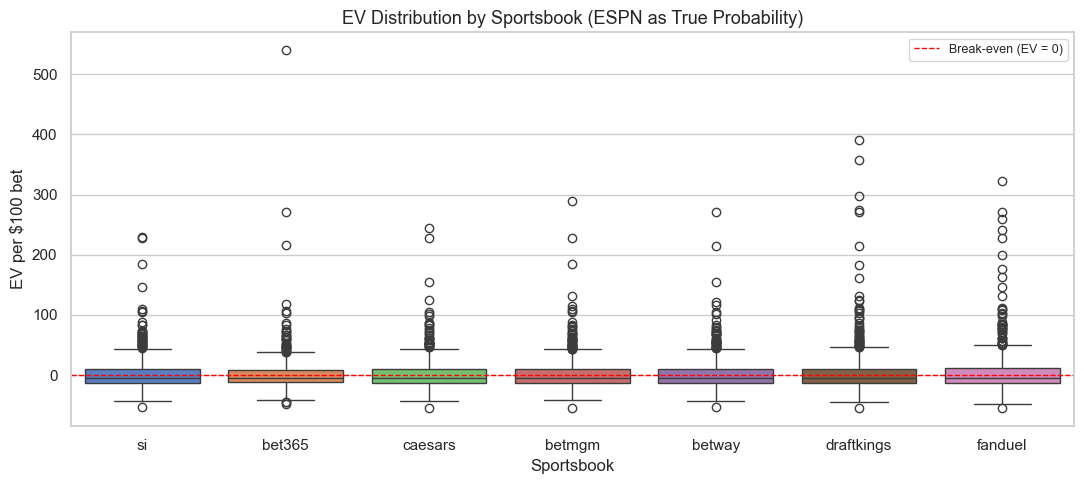

In [12]:
away_evs = ev_df[['book','ev_away']].rename(columns={'ev_away':'ev'})
home_evs = ev_df[['book','ev_home']].rename(columns={'ev_home':'ev'})
all_evs = pd.concat([away_evs, home_evs]).dropna()

fig, ax = plt.subplots(figsize=(11, 5))
book_order = all_evs.groupby('book')['ev'].median().sort_values(ascending=False).index
sns.boxplot(data=all_evs, x='book', y='ev', order=book_order, palette='muted', ax=ax)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Break-even (EV = 0)')
ax.set_title('EV Distribution by Sportsbook (ESPN as True Probability)', fontsize=13)
ax.set_xlabel('Sportsbook')
ax.set_ylabel('EV per $100 bet')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6a. Positive EV Summary — Which Book Offers the Most Edge?

**What:** Filter to EV > 0 only, then group by book to compute: count of positive EV opportunities, mean EV per bet, total cumulative EV, and the single highest EV opportunity.

**Why:** Isolates the "exploitable" side of the EV distribution. The total cumulative EV answers the hypothetical: *"If you had bet $100 on every positive-EV opportunity at this book (per ESPN's model), what would your theoretical gross return have been?"*

**Important caveat:** High total EV here means ESPN most frequently disagreed with that book in a way that appeared profitable — but Section 7 will show whether those disagreements were ESPN being right or ESPN being wrong.

**Figure meaning:** Bars sorted by total cumulative EV. Taller bar = more total theoretical edge at that book under ESPN's model.

In [13]:
pos_ev_summary = (
    all_evs[all_evs['ev'] > 0]
    .groupby('book')
    .agg(
        positive_ev_bets=('ev', 'count'),
        mean_ev=('ev', 'mean'),
        total_ev=('ev', 'sum'),
        max_ev=('ev', 'max')
    )
    .sort_values('total_ev', ascending=False)
)
pos_ev_summary

,positive_ev_bets,mean_ev,total_ev,max_ev
book,,,,
draftkings,221,34.7816,7686.7427,391.4000
fanduel,227,33.5097,7606.7025,322.4000
betmgm,226,26.6349,6019.4831,288.7000
si,226,26.5262,5994.9214,228.9000
betway,224,26.7545,5993.0019,270.6000
caesars,226,25.1395,5681.5354,243.8500
bet365,218,24.6152,5366.1083,539.8000


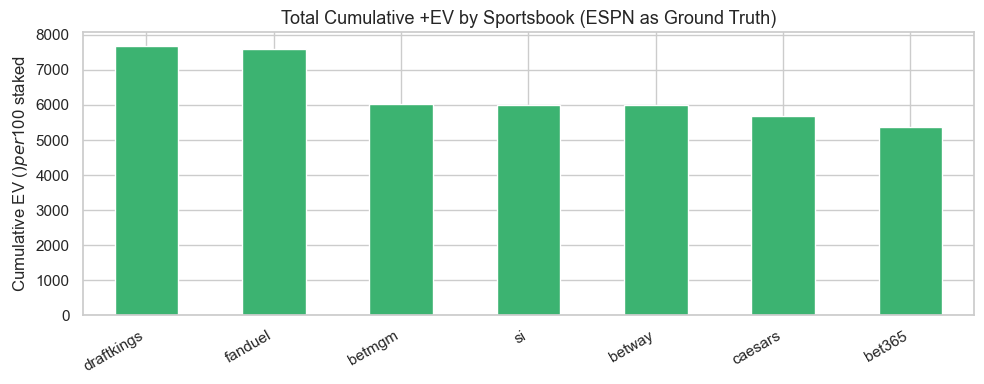

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
pos_ev_summary['total_ev'].plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Total Cumulative +EV by Sportsbook (ESPN as Ground Truth)', fontsize=13)
ax.set_ylabel('Cumulative EV ($) per $100 staked')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 7. EV vs. Actual Outcome — Did High EV Bets Win?

**What:** Bin every bet into 5 EV ranges and compare the actual win rate against what ESPN's model predicted. Then compute a Spearman rank correlation between EV and outcome to quantify the directional relationship.

**Why this is the most critical cell in the notebook:** It directly tests the ground truth assumption. If ESPN is a reliable model, the win rate should **rise monotonically** from left (negative EV) to right (high positive EV). High EV bets are high EV *because* ESPN gave the team a high win probability — so those teams should win more often.

**Figure meaning:**
- **x-axis** = EV bucket (how much theoretical edge ESPN's model assigned)
- **y-axis** = actual proportion of bets in that bucket that won
- **Black dashed line** = 50% random baseline
- **`n=` labels** = sample size per bucket (critical for interpreting bar height)
- **Expected shape if ESPN is good:** bars should rise left to right
- **Actual shape:** see output — and read the interpretation printed below the chart

**Spearman correlation:** A value near +1 = EV perfectly predicts outcomes (ESPN is excellent). Near 0 = no relationship. Near -1 = EV is *inversely* related to outcomes (ESPN is systematically wrong relative to the market).

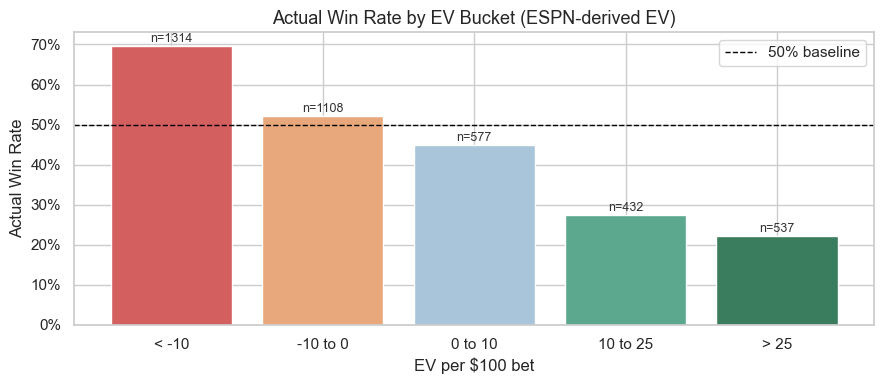

ev_bucket  n_bets  win_rate
    < -10    1314    0.6956
 -10 to 0    1108    0.5208
  0 to 10     577    0.4489
 10 to 25     432    0.2731
     > 25     537    0.2216

Spearman correlation (EV → outcome): r = -0.3483, p = 0.0000
⚠  FINDING: EV is NEGATIVELY correlated with actual outcomes.
   This means the market is a better probability estimator than ESPN.
   High ESPN-EV bets lose more often because ESPN was overrating those teams.
   The ground truth assumption does not hold — the market is more accurate than ESPN.


In [15]:
away_side = ev_df[['week','away_team','home_team','book','ev_away','espn_away_prob','away_ml','winner']].copy()
away_side.rename(columns={'ev_away':'ev','espn_away_prob':'espn_prob','away_ml':'ml','away_team':'team'}, inplace=True)
away_side['won'] = away_side['winner'] == away_side['team']
away_side['side'] = 'away'

home_side = ev_df[['week','away_team','home_team','book','ev_home','espn_home_prob','home_ml','winner']].copy()
home_side.rename(columns={'ev_home':'ev','espn_home_prob':'espn_prob','home_ml':'ml','home_team':'team'}, inplace=True)
home_side['won'] = home_side['winner'] == home_side['team']
home_side['side'] = 'home'

full = pd.concat([away_side, home_side]).dropna(subset=['ev','won'])
full['ml_display'] = full['ml'].apply(to_display_odds)

full['ev_bucket'] = pd.cut(full['ev'], bins=[-200, -10, 0, 10, 25, 200],
                            labels=['< -10', '-10 to 0', '0 to 10', '10 to 25', '> 25'])
bucket_stats = full.groupby('ev_bucket', observed=True).agg(
    n_bets=('won','count'),
    win_rate=('won','mean')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(bucket_stats['ev_bucket'].astype(str), bucket_stats['win_rate'],
              color=['#d45f5f','#e8a87c','#a8c5da','#5ba88f','#3a7d5e'], edgecolor='white')
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='50% baseline')
ax.set_title('Actual Win Rate by EV Bucket (ESPN-derived EV)', fontsize=13)
ax.set_xlabel('EV per $100 bet')
ax.set_ylabel('Actual Win Rate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend()
for bar, row in zip(bars, bucket_stats.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'n={row.n_bets}', ha='center', fontsize=9, color='#333')
plt.tight_layout()
plt.show()

print(bucket_stats.to_string(index=False))

# Spearman correlation — EV vs. actual outcome
valid = full.dropna(subset=['ev','won'])
corr, pval = spearmanr(valid['ev'], valid['won'].astype(int))
print(f'\nSpearman correlation (EV → outcome): r = {corr:.4f}, p = {pval:.4f}')

if corr < -0.05 and pval < 0.05:
    print('⚠  FINDING: EV is NEGATIVELY correlated with actual outcomes.')
    print('   This means the market is a better probability estimator than ESPN.')
    print('   High ESPN-EV bets lose more often because ESPN was overrating those teams.')
    print('   The ground truth assumption does not hold — the market is more accurate than ESPN.')
elif abs(corr) < 0.05 or pval >= 0.05:
    print('→  FINDING: No statistically significant relationship between ESPN EV and outcomes.')
    print('   ESPN divergences from the market have no consistent predictive value.')
else:
    print('✓  FINDING: EV is positively correlated with outcomes — ESPN shows predictive value.')

## 8. Export Results

In [16]:
os.makedirs('../outputs', exist_ok=True)

full_export = full[['week','team','side','book','espn_prob','ml','ev','won']].sort_values('ev', ascending=False)
full_export.to_csv('../outputs/1_ev_full.csv', index=False)

pos_ev = full[full['ev'] > 0][['week','team','side','book','espn_prob','ml','ev','won']].sort_values('ev', ascending=False)
pos_ev.to_csv('../outputs/1_ev_positive_only.csv', index=False)

pos_ev_summary.to_csv('../outputs/1_book_summary.csv')
bucket_stats.to_csv('../outputs/1_ev_bucket_stats.csv', index=False)

print('Exported:')
print(f'  1_ev_full.csv           — {len(full_export):,} rows (all bets, sorted by EV)')
print(f'  1_ev_positive_only.csv  — {len(pos_ev):,} rows (positive EV only)')
print(f'  1_book_summary.csv      — {len(pos_ev_summary)} books')
print(f'  1_ev_bucket_stats.csv   — {len(bucket_stats)} buckets (win rate by EV range)')

Exported:
  1_ev_full.csv           — 3,990 rows (all bets, sorted by EV)
  1_ev_positive_only.csv  — 1,568 rows (positive EV only)
  1_book_summary.csv      — 7 books
  1_ev_bucket_stats.csv   — 5 buckets (win rate by EV range)
